In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import linalg, optimize, stats
from sklearn.metrics import r2_score
import seaborn as sns
import xarray as xr
from typhon.physics import e_eq_water_mk

import matplotlib
matplotlib.rc('text', usetex = True)

In [2]:
sns.set_context('talk')

In [3]:
kludge = '1p82'

In [ ]:
#cm1_drop = xr.open_dataset(f'/Users/kristinswartz-schult/research/dns/results/data/grav01/cm1lp_kj/kludge/{kludge}/cm1out_dropdiag.nc',
#                           decode_times = False)
cm1_s = xr.open_dataset(f'cm1out_diag_s.nc',
                        decode_times = False)
cm1_w = xr.open_dataset(f'cm1out_diag_w.nc',
                        decode_times = False)
cm1_stats = xr.open_dataset(f'cm1out_stats.nc',
                            decode_times = False)

case = 'ndot0'
ntlp = xr.open_dataset(f'/Users/kristinswartz-schult/research/dns/results/data/grav01/pi/{case}/history.nc', decode_times = False)

In [5]:
for variable in ntlp.variables:
    print(f'{variable}\t:\t{ntlp[variable].attrs}')

dt	:	{'title': 'Model time step'}
utau	:	{'title': 'Friction velocity ustar'}
uwsfc	:	{'title': 'Lower surface stress'}
tnumpart	:	{'title': 'Total number of particles'}
tnumdrop	:	{'title': 'Total number of droplets defined by r>rc'}
tnumaerosol	:	{'title': 'Total number of aerosols defined by r<rc'}
tnum_destroy	:	{'title': 'Particles killed since last write'}
tdenum	:	{'title': 'Number of particles deactivated'}
tactnum	:	{'title': 'Number of particles activated'}
tnum100	:	{'title': 'Number of particles which did not converge Gauss-Newton solver this time step'}
tnumimpos	:	{'title': 'Number of particles which did not converge BOTH implicit solvers this time step'}
tot_reintro	:	{'title': 'Particles introduced this time step'}
Tsfc	:	{'title': 'Surface temperature'}
qsfc	:	{'title': 'Surface specific humidity qv'}
wtsfc	:	{'title': "Surface sensible heat flux <w'T'>"}
wqsfc	:	{'title': "Surface vapor flux <w'q'>"}
Swall	:	{'title': 'Humidity sink for Pi Chamber'}
meanRH	:	{'title':

In [6]:
#for variable in cm1_drop.variables:
#    print(f'{variable}\t:\t{cm1_drop[variable].attrs}')

In [7]:
for variable in cm1_stats.variables:
    print(f'{variable}\t:\t{cm1_stats[variable].attrs}')

mtime	:	{'long_name': 'model time (seconds since beginning of s (s)'}
wmax	:	{'long_name': 'max vertical velocity                    (m/s)'}
wmin	:	{'long_name': 'min vertical velocity                    (m/s)'}
zwmax	:	{'long_name': 'level of max vertical velocity           (m AGL)'}
zwmin	:	{'long_name': 'level of min vertical velocity           (m AGL)'}
umax	:	{'long_name': 'max u velocity (grid-rel)                (m/s)'}
umin	:	{'long_name': 'min u velocity (grid-rel)                (m/s)'}
sumax	:	{'long_name': 'max u velocity at lowst mod lev (grid-re (m/s)'}
sumin	:	{'long_name': 'min u velocity at lowst mod lev (grid-re (m/s)'}
vmax	:	{'long_name': 'max v velocity (grid-rel)                (m/s)'}
vmin	:	{'long_name': 'min v velocity (grid-rel)                (m/s)'}
svmax	:	{'long_name': 'max v velocity at lowst mod lev (grid-re (m/s)'}
svmin	:	{'long_name': 'min v velocity at lowst mod lev (grid-re (m/s)'}
ppimax	:	{'long_name': 'max nondimensional pressure perturbation (no

In [8]:
for variable in cm1_s.variables:
    print(f'{variable}\t:\t{cm1_s[variable].attrs}')

mtime	:	{'long_name': 'model time (since beginning of sim)      (s)'}
nstep	:	{'long_name': 'time steps (since beginning of sim)      (unitless)'}
umove	:	{'long_name': 'umove                                    (m/s)'}
vmove	:	{'long_name': 'vmove                                    (m/s)'}
ust	:	{'long_name': 'surface friction velocity                (m/s)'}
stau	:	{'long_name': 'surface stress                           (m2/s2)'}
znt	:	{'long_name': 'surface roughness length                 (m)'}
psfc	:	{'long_name': 'pressure at surface                      (Pa)'}
thflux	:	{'long_name': 'surface pot. temp. flux (Q*)             (K m/s)'}
qvflux	:	{'long_name': 'surface water vapor flux                 (g/g m/s)'}
rain	:	{'long_name': 'domain-averaged accum. rain at sfc       (cm)'}
prate	:	{'long_name': 'domain-averaged surface precipitation ra (kg/m2/s)'}
cwp	:	{'long_name': 'cloud water path                         (kg/(m^2))'}
rwp	:	{'long_name': 'rain water path                   

In [9]:
for variable in cm1_w.variables:
    print(f'{variable}\t:\t{cm1_w[variable].attrs}')

mtime	:	{'long_name': 'model time (since beginning of sim)      (s)'}
nstep	:	{'long_name': 'time steps (since beginning of sim)      (unitless)'}
umove	:	{'long_name': 'umove                                    (m/s)'}
vmove	:	{'long_name': 'vmove                                    (m/s)'}
ust	:	{'long_name': 'surface friction velocity                (m/s)'}
stau	:	{'long_name': 'surface stress                           (m2/s2)'}
znt	:	{'long_name': 'surface roughness length                 (m)'}
psfc	:	{'long_name': 'pressure at surface                      (Pa)'}
thflux	:	{'long_name': 'surface pot. temp. flux (Q*)             (K m/s)'}
qvflux	:	{'long_name': 'surface water vapor flux                 (g/g m/s)'}
rain	:	{'long_name': 'domain-averaged accum. rain at sfc       (cm)'}
prate	:	{'long_name': 'domain-averaged surface precipitation ra (kg/m2/s)'}
cwp	:	{'long_name': 'cloud water path                         (kg/(m^2))'}
rwp	:	{'long_name': 'rain water path                   

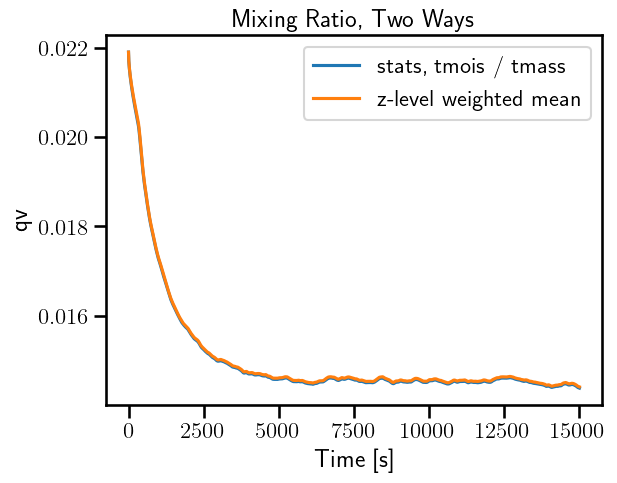

In [10]:
cm1_dz = xr.DataArray(np.diff(cm1_w.lev), dims = 'lev')
ntlp_dz = xr.DataArray(np.diff(ntlp.zw), dims = 'zu')

plt.plot(cm1_stats.mtime[:,0,0], cm1_stats.tmois[:, 0, 0] / cm1_stats.tmass[:, 0, 0], label = 'stats, tmois / tmass')
plt.plot(cm1_s.mtime[:,0,0], cm1_s.qv.weighted(cm1_dz).mean(dim = 'lev')[:,0,0], label = 'z-level weighted mean')
plt.xlabel('Time [s]')
plt.ylabel('qv')
plt.title('Mixing Ratio, Two Ways')
plt.legend()

Text(0.5, 1.0, 'CM1 RH')

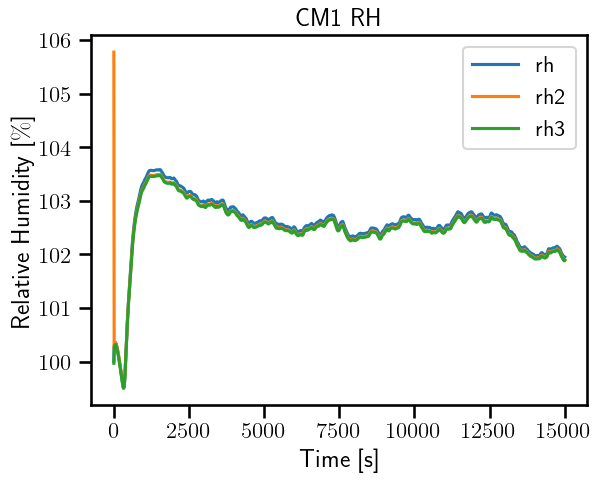

In [11]:
#plt.plot(cm1_sw_s['mtime'][:,0,0], np.mean(cm1_sw_s['rh'], axis = 1)[:, 0, 0] * 100, label = f'cm1_sw = {wall_sat}')
plt.plot(cm1_s['mtime'][:,0,0], cm1_s.rh.weighted(cm1_dz).mean(dim = 'lev')[:,0,0] * 100, label = 'rh')
plt.plot(cm1_s['mtime'][:,0,0], cm1_s.rh2.weighted(cm1_dz).mean(dim = 'lev')[:,0,0] * 100, label = 'rh2')
plt.plot(cm1_s['mtime'][:,0,0], cm1_s.rh3.weighted(cm1_dz).mean(dim = 'lev')[:,0,0] * 100, label = 'rh3')
plt.xlabel('Time [s]')
plt.ylabel(r'Relative Humidity [$\%$]')
plt.legend()
plt.title('CM1 RH')

In [20]:
cm1_mask = cm1_s['mtime'] > 5000

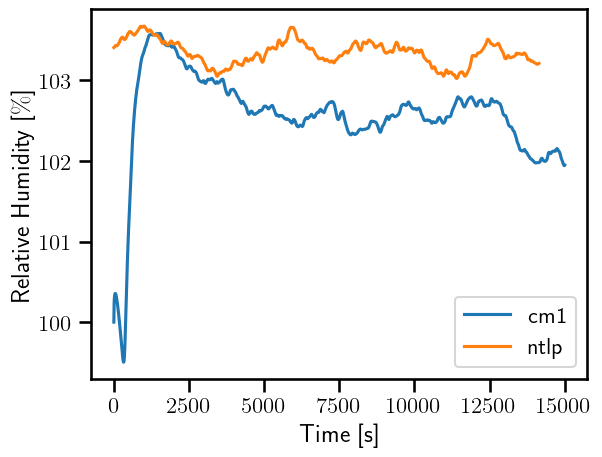

In [12]:
plt.plot(cm1_s['mtime'][:,0,0], cm1_s.rh.weighted(cm1_dz).mean(dim = 'lev')[:,0,0] * 100, label = 'cm1')
plt.plot(ntlp.time, ntlp.meanRH, label = 'ntlp')

plt.xlabel('Time [s]')
plt.ylabel(r'Relative Humidity [$\%$]')
plt.legend()

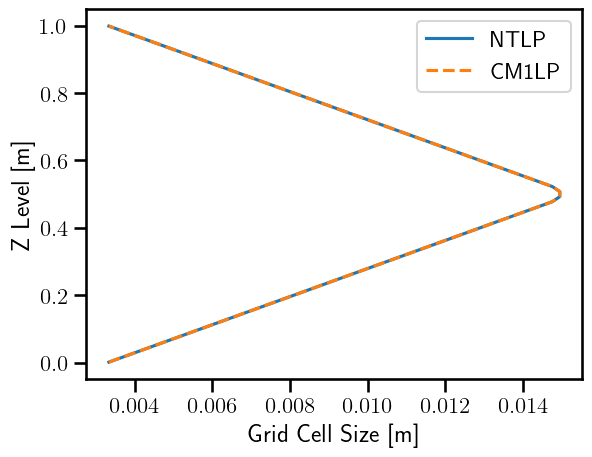

In [13]:
fig, ax = plt.subplots()
ax.plot(ntlp_dz, ntlp.zu, label = 'NTLP')
ax.plot(cm1_dz * 1000, cm1_s.lev * 1000, label = 'CM1LP', ls = '--')
ax.set_xlabel('Grid Cell Size [m]')
ax.set_ylabel('Z Level [m]')
ax.legend()

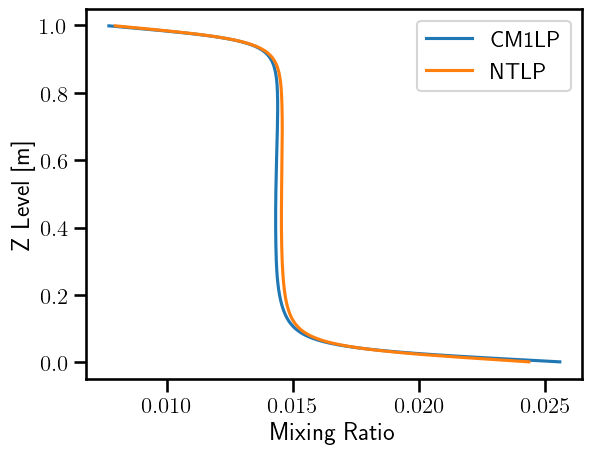

In [21]:
ntlp_specific_humidity = ntlp.txym[:,1,:].mean(dim='time')
ntlp_mixing_ratio =  ntlp_specific_humidity / ( 1 - ntlp_specific_humidity)

plt.plot(cm1_s.qv.where(cm1_mask, drop = True).mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1LP')
plt.plot(ntlp_mixing_ratio, ntlp.zu, label = 'NTLP')
plt.xlabel('Mixing Ratio')
plt.ylabel('Z Level [m]')
plt.legend()

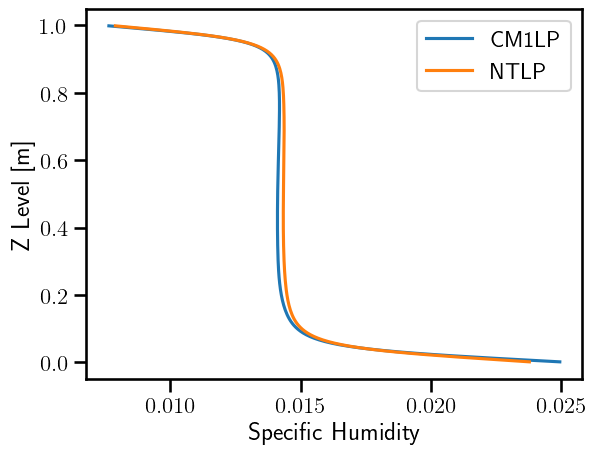

In [22]:
plt.plot(cm1_s.shv.where(cm1_mask, drop = True).mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1LP')
plt.plot(ntlp_specific_humidity, ntlp.zu, label = 'NTLP')
plt.xlabel('Specific Humidity')
plt.ylabel('Z Level [m]')
plt.legend()

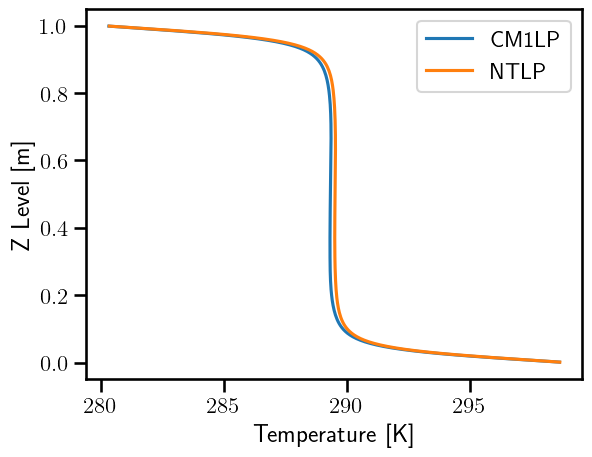

In [23]:
plt.plot(cm1_s.t.where(cm1_mask, drop = True).mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1LP')
plt.plot(ntlp.tempxym.mean(dim = 'time'), ntlp.zu, label = 'NTLP')
plt.xlabel('Temperature [K]')
plt.ylabel('Z Level [m]')
plt.legend()

In [24]:
plt.plot(ntlp_satvap, ntlp.zu, label = 'NTLP')
plt.plot(cm1_satvap, cm1_s.lev * 1000, label = 'CM1')
plt.xlabel('Saturation Vapor Pressure [Pa]')
plt.ylabel('Z Levels [m]')
plt.legend()

NameError: name 'ntlp_satvap' is not defined

Text(0, 0.5, 'Z Levels [m]')

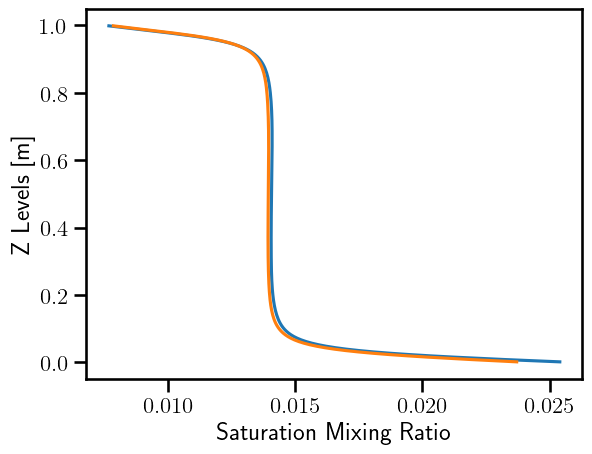

In [119]:
R_v = 461.5 # J / kg K

ntlp_t = ntlp.tempxym
cm1_t = cm1_s.t.where(cm1_mask, drop = True)

ntlp_satvap = e_eq_water_mk(ntlp_t)
cm1_satvap = e_eq_water_mk(cm1_t)

cm1_rho = cm1_s.rho.where(cm1_mask, drop = True)
ntlp_rho = ntlp.rho_base

cm1_qsat = cm1_satvap / (R_v * cm1_t * cm1_rho)
ntlp_qsat = ntlp_satvap / (R_v * ntlp_t * ntlp_rho)

plt.plot(cm1_qsat.mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1')
plt.plot(ntlp_qsat.mean(dim = 'time'), ntlp.zu, label = 'NTLP')
plt.xlabel(r'Saturation Mixing Ratio')
plt.ylabel('Z Levels [m]')
#plt.legend(bbox_to_anchor=(0.5,0.5))

In [139]:
def eslf(p, T):
    # Bolton (1980, MWR)
    esl = 611.2 * np.exp(17.67 * (T - 273.15) / (T - 29.65))
    return np.minimum(esl, 0.5 * p)

def rslf(p, T):
    rd, rv = 287.04, 461.5
    eps = rd / rv
    esl = eslf(p, T)
    rsl = eps * esl / (p - esl)
    return rsl

In [167]:
rd = 287.04
rv = 461.5
cp = 1005.7
p00 = 1.0e5
cpdrd = cp / rd

rh_inst = (cm1_s.qv / rslf(cm1_s.prs, cm1_s.t)) * 100
cm1_rh_calc = rh_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

prs_inst = p00 * cm1_s.ppi**cpdrd
cm1_prs_calc = prs_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

t_inst = cm1_s.th * cm1_s.ppi
cm1_t_calc = t_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

rh_inst2 = (cm1_s.qv / rslf(prs_inst, t_inst)) * 100
cm1_rh_calc2 = rh_inst2.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

rho_inst = prs / (t * (rd + cm1_s.qv * rv))
cm1_rho_calc = rho_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

cm1_rh = cm1_s.rh.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100
cm1_rh2 = cm1_s.rh2.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100
cm1_rh3 = cm1_s.rh3.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100
cm1_prs = cm1_s.prs.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]
cm1_t = cm1_s.t.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]
cm1_rho = cm1_s.rho.where(cm1_mask, drop = True).mean(dim='time')[:,0,0]

rh2_inst = (cm1_s.rho * cm1_s.qv * rv * cm1_s.t) / eslf(cm1_s.prs, cm1_s.t) * 100
cm1_rh2_calc = rh2_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

rh2_inst2 = (rho_inst * cm1_s.qv * rv * t_inst) / eslf(prs_inst, t_inst) * 100
cm1_rh2_calc2 = rh2_inst2.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

rh3_inst = ((cm1_s.qv / (1 + cm1_s.qv)) * (cm1_s.prs / (rd * cm1_s.t * (1 + 0.61 * cm1_s.qv))) * rv * cm1_s.t) \
           / eslf(cm1_s.prs, cm1_s.t) * 100
cm1_rh3_calc = rh3_inst.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

rh3_inst2 = ((cm1_s.qv / (1 + cm1_s.qv)) * (prs_inst / (rd * t_inst * (1 + 0.61 * cm1_s.qv))) * rv * t_inst) \
            / eslf(prs_inst, t_inst) * 100
cm1_rh3_calc2 = rh3_inst2.where(cm1_mask, drop=True).mean(dim='time')[:,0,0]

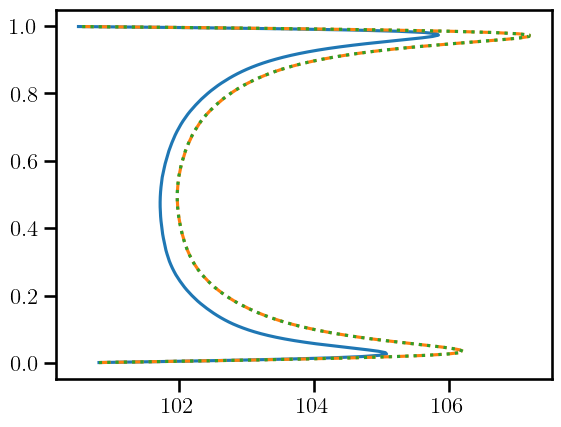

In [169]:
plt.plot(cm1_rh, cm1_s.lev * 1000)
plt.plot(cm1_rh_calc, cm1_s.lev * 1000, ls = '--')
plt.plot(cm1_rh_calc2, cm1_s.lev * 1000, ls = ':')

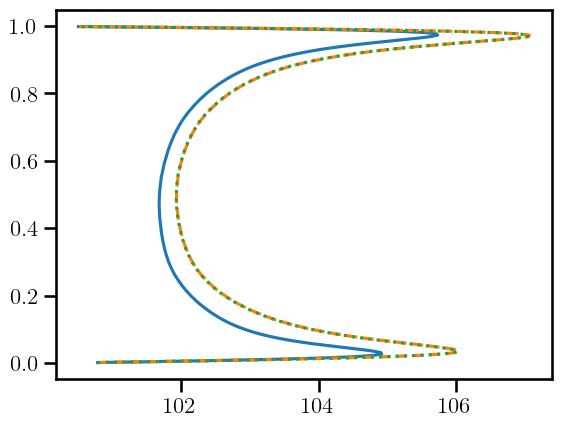

In [170]:
plt.plot(cm1_rh2, cm1_s.lev * 1000)
plt.plot(cm1_rh2_calc, cm1_s.lev * 1000, ls = '--')
plt.plot(cm1_rh2_calc2, cm1_s.lev * 1000, ls = ':')

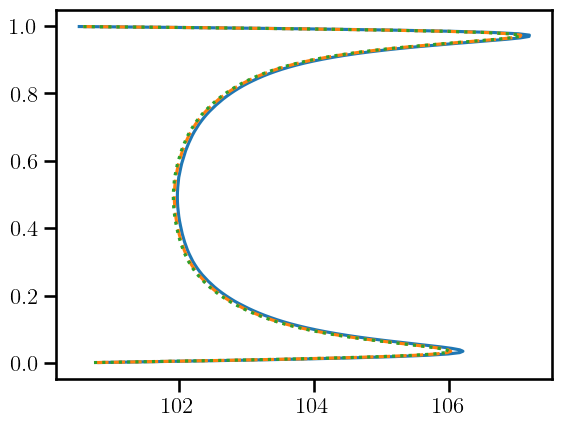

In [173]:
plt.plot(cm1_rh_calc2, cm1_s.lev * 1000)
plt.plot(cm1_rh2_calc2, cm1_s.lev * 1000, ls = '--')
plt.plot(cm1_rh3_calc2, cm1_s.lev * 1000, ls = ':')

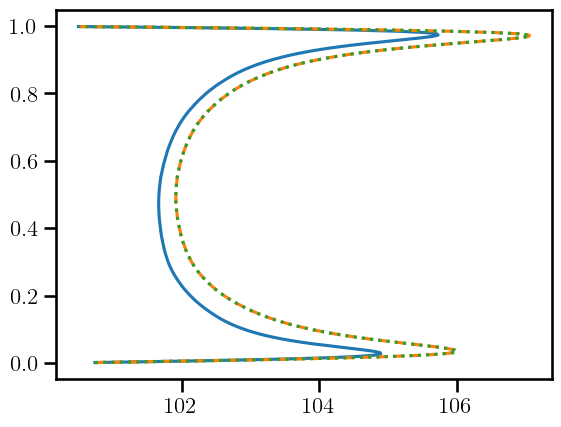

In [171]:
plt.plot(cm1_rh3, cm1_s.lev * 1000)
plt.plot(cm1_rh3_calc, cm1_s.lev * 1000, ls = '--')
plt.plot(cm1_rh3_calc2, cm1_s.lev * 1000, ls = ':')

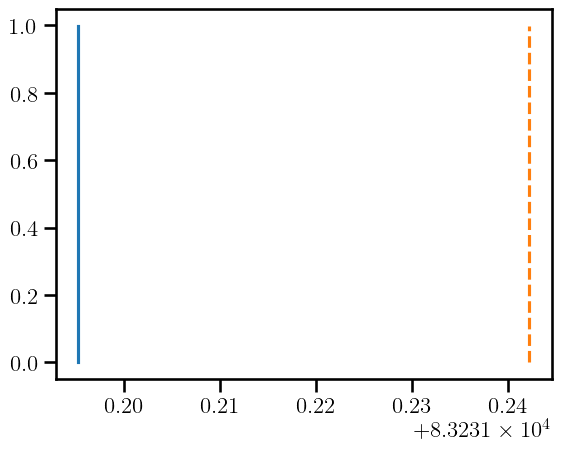

In [107]:
plt.plot(cm1_prs, cm1_s.lev * 1000)
plt.plot(cm1_prs_calc, cm1_s.lev * 1000, ls = '--')

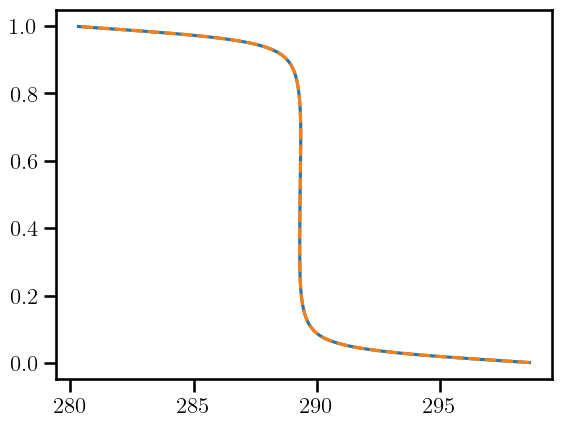

In [108]:
plt.plot(cm1_t, cm1_s.lev * 1000)
plt.plot(cm1_t_calc, cm1_s.lev * 1000, ls = '--')

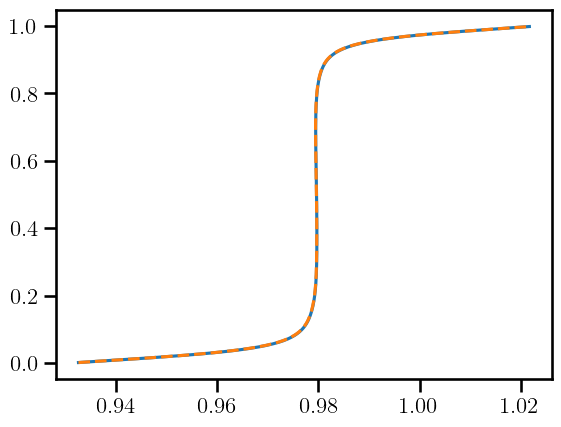

In [109]:
plt.plot(cm1_rho, cm1_s.lev * 1000)
plt.plot(cm1_rho_calc, cm1_s.lev * 1000, ls = '--')

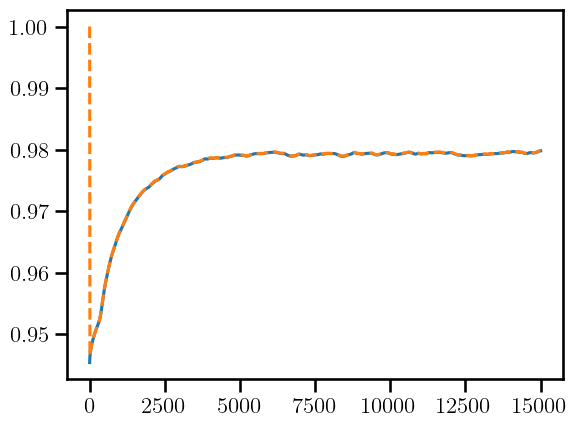

In [102]:
plt.plot(cm1_s['mtime'][:,0,0], rho.weighted(cm1_dz).mean(dim = 'lev')[:,0,0])
plt.plot(cm1_s['mtime'][:,0,0], cm1_s.rho.weighted(cm1_dz).mean(dim = 'lev')[:,0,0], ls = '--')

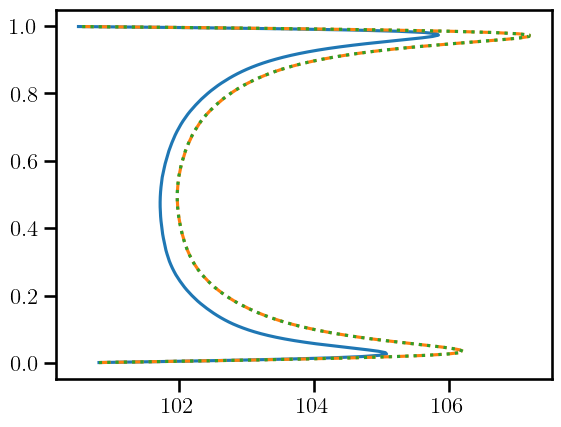

In [ ]:
plt.plot(cm1_prs, cm1_s.lev * 1000)
plt.plot(cm1_rh_calc, cm1_s.lev * 1000, ls = '--')
plt.plot(cm1_rh_calc2, cm1_s.lev * 1000, ls = ':')

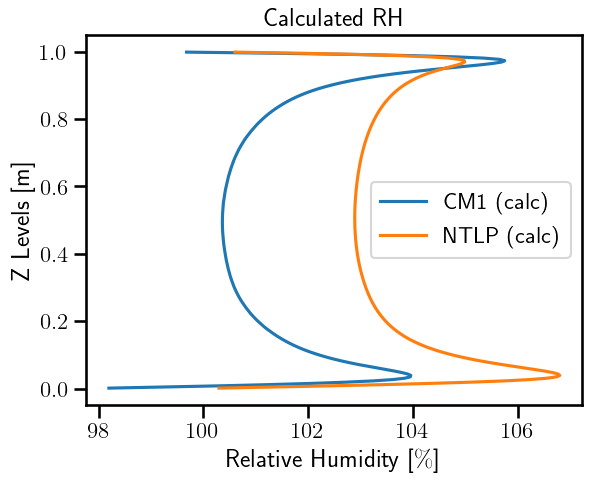

In [114]:
cm1_q = cm1_s.shv.where(cm1_mask, drop = True)
ntlp_q = ntlp.txym[:,1,:]

cm1_rh = cm1_q / cm1_qsat * 100
ntlp_rh = ntlp_q / ntlp_qsat * 100

plt.plot(cm1_rh.mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1 (calc)')
plt.plot(ntlp_rh.mean(dim = 'time'), ntlp.zu, label = 'NTLP (calc)')
plt.xlabel(r'Relative Humidity [$\%$]')
plt.ylabel('Z Levels [m]')
plt.title('Calculated RH')
plt.legend()

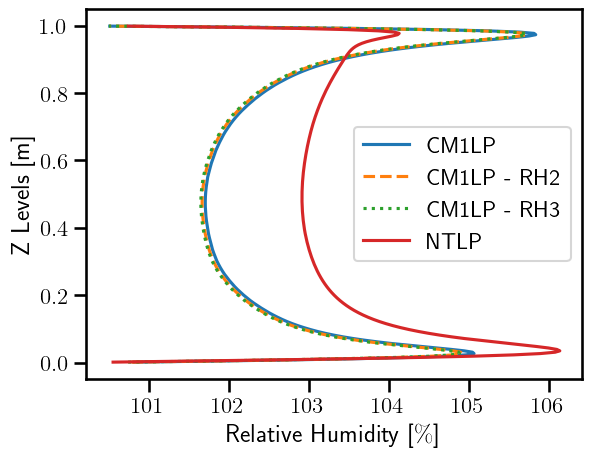

In [23]:
cm1_mask = cm1_s.mtime > 6000
plt.plot(cm1_s.rh.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, label = 'CM1LP')
plt.plot(cm1_s.rh2.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, ls = '--', label = 'CM1LP - RH2')
plt.plot(cm1_s.rh3.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, ls = ':', label = 'CM1LP - RH3')
plt.plot(ntlp.RHxym.mean(dim='time'), ntlp.zu, label = 'NTLP')
plt.ylabel('Z Levels [m]')
plt.xlabel(r'Relative Humidity [$\%$]')
plt.legend()

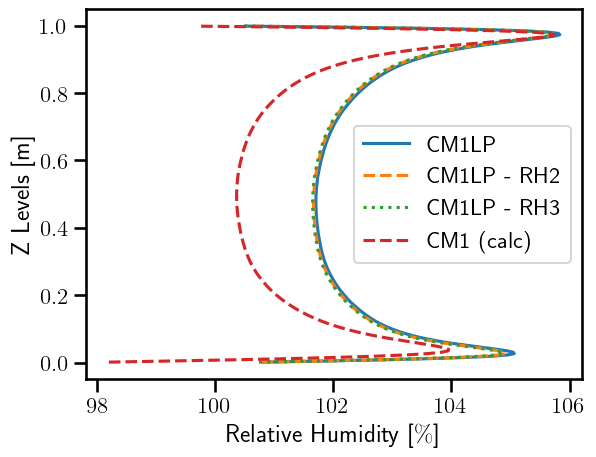

In [149]:
plt.plot(cm1_s.rh.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, label = 'CM1LP')
plt.plot(cm1_s.rh2.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, ls = '--', label = 'CM1LP - RH2')
plt.plot(cm1_s.rh3.where(cm1_mask, drop = True).mean(dim='time')[:,0,0] * 100, cm1_s.lev * 1000, ls = ':', label = 'CM1LP - RH3')
plt.plot(cm1_rh.mean(dim = 'time')[:,0,0], cm1_s.lev * 1000, label = 'CM1 (calc)', ls = '--')
plt.xlabel(r'Relative Humidity [$\%$]')
plt.ylabel('Z Levels [m]')
plt.legend()

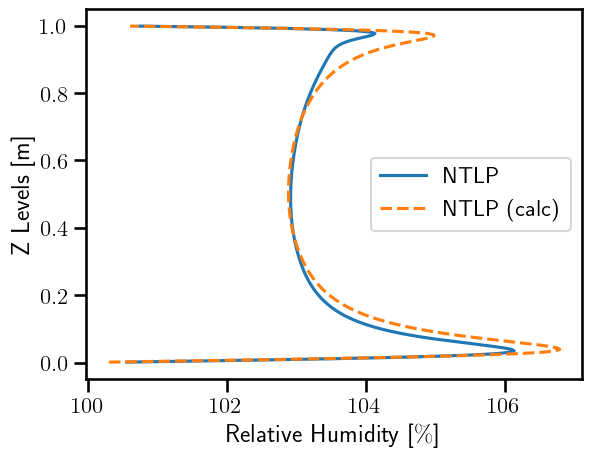

In [148]:
plt.plot(ntlp.RHxym.mean(dim='time'), ntlp.zu, label = 'NTLP')
plt.plot(ntlp_rh.mean(dim = 'time'), ntlp.zu, label = 'NTLP (calc)', ls = '--')
plt.xlabel(r'Relative Humidity [$\%$]')
plt.ylabel('Z Levels [m]')
plt.legend()

NTLP Nu:  9.902436097153114
CM1 Nu:  10.168927586434235


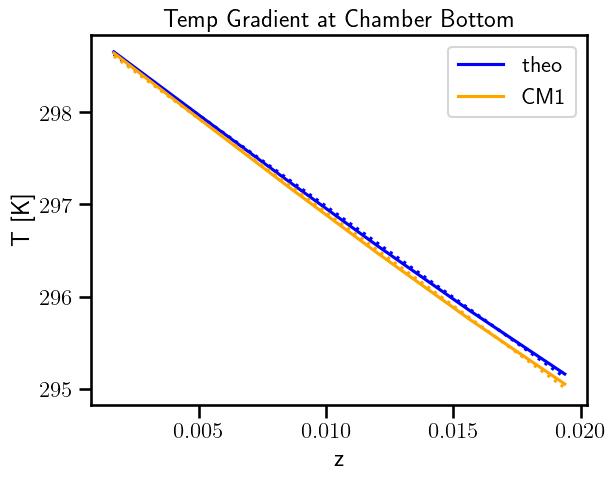

In [138]:
grids = 6
plt.plot(ntlp.zu[:grids], ntlp.tempxym.mean(dim='time')[:grids], label = 'ntlp', c = 'blue')

ntlp_res = stats.linregress(ntlp.zu[:grids], ntlp.tempxym.mean(dim='time')[:grids])
plt.plot(ntlp.zu[:grids], ntlp_res.slope * ntlp.zu[:grids] + ntlp_res.intercept, c = 'blue', ls = ':')

plt.plot(cm1_s.lev[:grids] * 1000, cm1_s.t.where(cm1_mask, drop = True).mean(dim='time')[:grids, 0, 0], label = 'CM1', c = 'orange')

cm1_res = stats.linregress(cm1_s.lev[:grids] * 1000, cm1_s.t.where(cm1_mask, drop = True).mean(dim='time')[:grids, 0, 0])
plt.plot(cm1_s.lev[:grids] * 1000, cm1_res.slope * cm1_s.lev[:grids] * 1000 + cm1_res.intercept, c = 'orange', ls = ':')

plt.ylabel('T [K]')
plt.xlabel('z')
plt.title('Temp Gradient at Chamber Bottom')
plt.legend()

print('NTLP Nu: ', - (1 / 20) * ntlp_res.slope)
print('CM1 Nu: ', - (1 / 20) * cm1_res.slope)

NTLP Nu:  9.911425665244607
CM1 Nu:  9.493768955734435


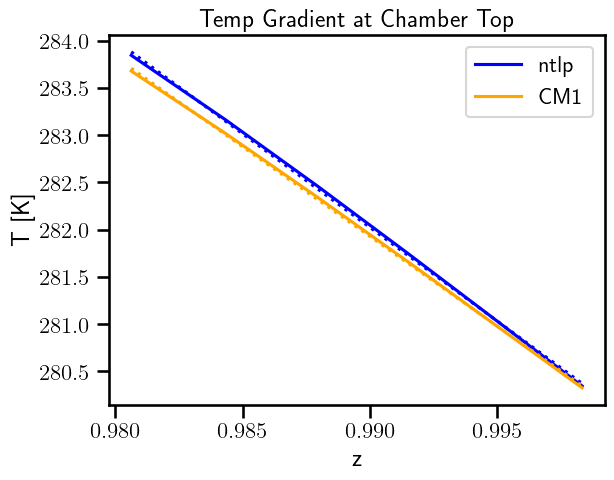

In [144]:
grids = 6
plt.plot(ntlp.zu[-grids:], ntlp.tempxym.mean(dim='time')[-grids:], label = 'ntlp', c = 'blue')

ntlp_res = stats.linregress(ntlp.zu[-grids:], ntlp.tempxym.mean(dim='time')[-grids:])
plt.plot(ntlp.zu[-grids:], ntlp_res.slope * ntlp.zu[-grids:] + ntlp_res.intercept, c = 'blue', ls = ':')

plt.plot(cm1_s.lev[-grids:] * 1000, cm1_s.t.where(cm1_mask, drop = True).mean(dim='time')[-grids:, 0, 0], label = 'CM1', c = 'orange')

cm1_res = stats.linregress(cm1_s.lev[-grids:] * 1000, cm1_s.t.where(cm1_mask, drop = True).mean(dim='time')[-grids:, 0, 0])
plt.plot(cm1_s.lev[-grids:] * 1000, cm1_res.slope * cm1_s.lev[-grids:] * 1000 + cm1_res.intercept, c = 'orange', ls = ':')

plt.ylabel('T [K]')
plt.xlabel('z')
plt.title('Temp Gradient at Chamber Top')
plt.legend()

nu = 1.57e-5 # kinematic viscosity, m^2/s
Pr = 0.715 # prandtl number
kappa = nu / Pr
dT = 20
H = 1

print('NTLP Nu: ', - (H / dT) * ntlp_res.slope)
print('CM1 Nu: ', - (H / dT) * cm1_res.slope)

10.395249366760254 +- 0.1432906836271286


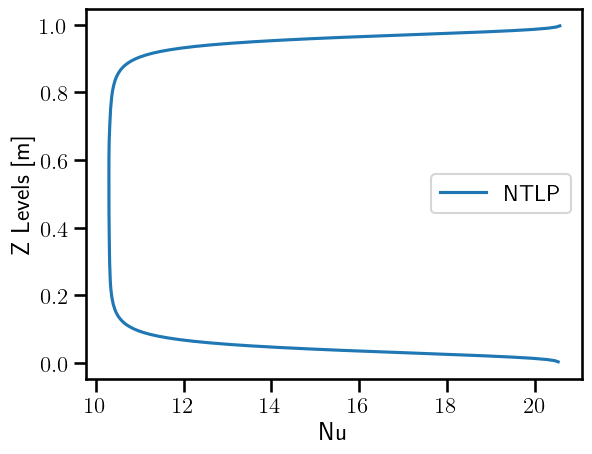

In [156]:
avg_T = ntlp.tempxym.mean(dim='time').interp(zu=ntlp.zw)
avg_w = ntlp.wxym.mean(dim='time')
avg_wTle = ntlp.wtle.mean(dim='time')[0]
avg_wTsb = ntlp.wtsb.mean(dim='time')[0]
dz_avg_T = ntlp.tempxym.mean(dim='time').differentiate('zu').interp(zu=ntlp.zw)

ntlp_wT = avg_w * avg_T + avg_wTle + avg_wTsb
ntlp_q =  ntlp_wT - kappa * dz_avg_T
ntlp_Nu = ntlp_q / (kappa * (dT / H))

plt.plot(ntlp_Nu, ntlp.zw, label = 'NTLP')
ntlp_meanNu = np.mean(ntlp_Nu[(ntlp.zw > 0.1) & (ntlp.zw < 0.9)]).data
ntlp_stdNu = np.std(ntlp_Nu[(ntlp.zw > 0.1) & (ntlp.zw < 0.9)]).data
print(f'{ntlp_meanNu} +- {ntlp_stdNu}')

avg_T = cm1_s.t.where(cm1_mask, drop = True).mean(dim='time').interp(lev=ntlp.zw)
avg_w = cm1_w.w.where(cm1_mask, drop = True).mean(dim='time')
#avg_wTle = grav01.wtle.mean(dim='time')[0]
#avg_wTsb = grav01.wtsb.mean(dim='time')[0]
#dz_avg_T = grav01.tempxym.mean(dim='time').differentiate('zu').interp(zu=grav01.zw)

#grav01_wT = avg_w * avg_T + avg_wTle + avg_wTsb
#grav01_q = grav01_wT - ntlp_kappa * dz_avg_T
#grav01_Nu = grav01_q / (grav01_kappa * (grav01_dT / grav01_H))

#plt.plot(grav01_Nu, grav01.zw, label = 'grav01')
#grav01_meanNu = np.mean(grav01_Nu[(grav01.zw > 0.1) & (grav01.zw < 0.9)]).data
#grav01_stdNu = np.std(grav01_Nu[(grav01.zw > 0.1) & (grav01.zw < 0.9)]).data
#print(f'{grav01_meanNu} +- {grav01_stdNu}')

plt.xlabel('Nu')
plt.ylabel('Z Levels [m]')
plt.legend()

In [175]:
cm1_s.ppi

<xarray.DataArray 'ppi' (time: 1501, lev: 128, lat: 1, lon: 1)> Size: 769kB
array([[[[0.948959]],

        ...,

        [[0.948959]]],


       ...,


       [[[0.948959]],

        ...,

        [[0.948959]]]], dtype=float32)
Coordinates:
  * time     (time) float64 12kB 0.0 8.76e+03 1.752e+04 ... 1.314e+07 1.315e+07
  * lev      (lev) float64 1kB 1.667e-06 5.04e-06 ... 0.000995 0.0009983
  * lat      (lat) float64 8B 0.0
  * lon      (lon) float64 8B 0.0
Attributes:
    long_name:  nondimensional pressure                  (nondimensional)

- nusselt number with z (two or three ways)
- compare Nu(Ra,Pr) to known scaling laws
- ~~dz over z~~
- eta vs dz over z
- compare turbulent velocity profiles
- kinetic boundary layer calc
    - 99% bulk rms
    - u'_max / d_z u' at wall
- thermal boundary layer calc
- ~~T with height~~
- ~~RH with height~~
    - find multiple ways to calculate RH with height
- ~~qv with height~~
- look at horizontal dist of w or T at midplane (over time? animation?)
- LSC magnitude and angle
- TKE with z